# HW3 - Problem 1: Deep Learning with PyTorch

This notebook follows the four sections of the assigned
[60 Minute Blitz](https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html).
The examples below are adapted from the linked PyTorch tutorials, with explanations,
reproducible random seeds, and outputs from execution.

Run the cells in order. The first run downloads the tutorial's ResNet-18 weights
and CIFAR-10 dataset into `data/`; later runs reuse those files. The final classifier
uses all 50,000 training images for two epochs and all 10,000 test images for evaluation.

## Environment and reproducibility

Required packages: `torch`, `torchvision`, `numpy`, and `matplotlib`, plus a Jupyter
kernel. Select the HW3 Python environment. The versions and device used for this
execution are printed below. Seed 42 fixes the random examples, initial weights,
and training shuffle; numerical results can still vary across hardware or package versions.
Data-loader workers are set to zero for Windows notebook compatibility. The
autograd ResNet examples run on CPU, as specified in that tutorial.

In [1]:
from pathlib import Path
import os
import random
import sys
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
import torch.nn.functional as F
import torchvision
from torchvision.transforms import v2
from torchvision.models import resnet18, ResNet18_Weights
from IPython.display import Markdown, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

# Small tutorial batches avoid excessive CPU thread overhead.
torch.set_num_threads(min(2, os.cpu_count() or 1))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = Path.cwd() / 'data'
DATA_ROOT.mkdir(parents=True, exist_ok=True)
torch.hub.set_dir(str(DATA_ROOT / 'torch_hub'))

print('Python:', sys.version.split()[0])
print('Interpreter:', sys.executable)
print('PyTorch:', torch.__version__)
print('TorchVision:', torchvision.__version__)
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('Classifier device:', DEVICE)
print('CPU threads:', torch.get_num_threads())
print('Data directory:', DATA_ROOT)

Python: 3.12.10
Interpreter: C:\Users\Bayu Febriansyah\venvs\ae498-hw3\Scripts\python.exe
PyTorch: 2.14.1+cpu
TorchVision: 0.29.1+cpu
NumPy: 2.5.2
Matplotlib: 3.11.2
Classifier device: cpu
CPU threads: 2
Data directory: C:\Users\Bayu Febriansyah\Desktop\Important\US\Academics\Semester 3\AE 498 Data Driven Modeling and Optimization\HW3\hw3-nns-main\data


## 1. Tensors

Source: [Tensors](https://docs.pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html).

Tensors hold model inputs, outputs, and parameters. This section demonstrates
creation from Python data, NumPy arrays, and other tensors, followed by random
and constant initialization.

In [2]:
values = [[1, 2], [3, 4]]
from_data = torch.tensor(values)
from_array = torch.from_numpy(np.array(values))
same_shape_ones = torch.ones_like(from_data)
same_shape_random = torch.rand_like(from_data, dtype=torch.float32)

for name, value in {
    'Python data': from_data,
    'NumPy array': from_array,
    'ones_like': same_shape_ones,
    'rand_like (float)': same_shape_random,
    'Random 2 x 3': torch.rand(2, 3),
    'Ones 2 x 3': torch.ones(2, 3),
    'Zeros 2 x 3': torch.zeros(2, 3),
}.items():
    print(f'{name}:\n{value}\n')

Python data:
tensor([[1, 2],
        [3, 4]])

NumPy array:
tensor([[1, 2],
        [3, 4]])

ones_like:
tensor([[1, 1],
        [1, 1]])

rand_like (float):
tensor([[0.8823, 0.9150],
        [0.3829, 0.9593]])

Random 2 x 3:
tensor([[0.3904, 0.6009, 0.2566],
        [0.7936, 0.9408, 0.1332]])

Ones 2 x 3:
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Zeros 2 x 3:
tensor([[0., 0., 0.],
        [0., 0., 0.]])



In [3]:
attributes_example = torch.rand(3, 4)
print('Shape:', attributes_example.shape)
print('Data type:', attributes_example.dtype)
print('Original device:', attributes_example.device)
on_device = attributes_example.to(DEVICE)
print('After .to(DEVICE):', on_device.device)

Shape: torch.Size([3, 4])
Data type: torch.float32
Original device: cpu
After .to(DEVICE): cpu


### Operations and NumPy interoperability

`*` multiplies corresponding entries; `@` performs matrix multiplication.
Concatenation joins tensors along a selected dimension. An operation ending in
`_` changes its tensor in place. CPU tensors and NumPy arrays can share storage,
so a change through one view may also appear in the other.

In [4]:
matrix = torch.ones(4, 4)
matrix[:, 1] = 0
joined = torch.cat((matrix, matrix, matrix), dim=1)
print('After column indexing:\n', matrix)
print('Concatenated shape:', joined.shape)
print('Element-wise product:\n', matrix * matrix)
print('Matrix product:\n', matrix @ matrix.T)

in_place_example = matrix.clone()
in_place_example.add_(5)
print('In-place addition:\n', in_place_example)
print('Original preserved by clone:\n', matrix)

After column indexing:
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
Concatenated shape: torch.Size([4, 12])
Element-wise product:
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
Matrix product:
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])
In-place addition:
 tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])
Original preserved by clone:
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [5]:
cpu_tensor = torch.ones(5)
numpy_view = cpu_tensor.numpy()
cpu_tensor.add_(1)
print('Tensor changed:', cpu_tensor)
print('NumPy sees the same change:', numpy_view)

numpy_array = np.ones(5)
tensor_view = torch.from_numpy(numpy_array)
np.add(numpy_array, 1, out=numpy_array)
print('NumPy changed:', numpy_array)
print('Tensor sees the same change:', tensor_view)

# A copy has independent storage.
independent_tensor = tensor_view.clone()
numpy_array[0] = 99
print('Shared tensor after another NumPy change:', tensor_view)
print('Independent clone:', independent_tensor)

Tensor changed: tensor([2., 2., 2., 2., 2.])
NumPy sees the same change: [2. 2. 2. 2. 2.]
NumPy changed: [2. 2. 2. 2. 2.]
Tensor sees the same change: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
Shared tensor after another NumPy change: tensor([99.,  2.,  2.,  2.,  2.], dtype=torch.float64)
Independent clone: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


## 2. A Gentle Introduction to autograd

Source: [Autograd](https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html).

A forward pass computes a prediction; `backward()` computes derivatives;
the optimizer updates parameters. The tutorial's pretrained ResNet-18 example
below performs one update using synthetic inputs and synthetic targets.
Its summed difference is a demonstration scalar, not a useful classification loss.

In [6]:
torch.manual_seed(SEED)
autograd_model = resnet18(weights=ResNet18_Weights.DEFAULT, progress=False)
autograd_model.train()
dummy_image = torch.rand(1, 3, 64, 64)
dummy_target = torch.rand(1, 1000)
autograd_optimizer = optim.SGD(autograd_model.parameters(), lr=0.01, momentum=0.9)
weight_before = autograd_model.fc.weight.detach().clone()

autograd_optimizer.zero_grad(set_to_none=True)
dummy_prediction = autograd_model(dummy_image)
demonstration_scalar = (dummy_prediction - dummy_target).sum()
demonstration_scalar.backward()
print('Prediction shape:', tuple(dummy_prediction.shape))
print('Scalar for backward:', demonstration_scalar.item())
print('Classifier gradient norm:', autograd_model.fc.weight.grad.norm().item())
autograd_optimizer.step()
print('Classifier weight change norm:',
      (autograd_model.fc.weight.detach() - weight_before).norm().item())

Prediction shape: (1, 1000)
Scalar for backward: -509.0904846191406
Classifier gradient norm: 689.2847900390625
Classifier weight change norm: 6.892790794372559


### Check derivatives and a vector-Jacobian product

For the tutorial's $Q=3a^3-b^2$, the derivatives are $9a^2$ and $-2b$.
A vector output needs an upstream vector for `backward()`. The optional
two-output example also checks the product $J^T v$ against its analytic value.

In [7]:
a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)
q = 3 * a**3 - b**2
q.backward(gradient=torch.ones_like(q))
print('Q:', q.detach())
print('dQ/da:', a.grad, '| expected:', 9 * a.detach()**2)
print('dQ/db:', b.grad, '| expected:', -2 * b.detach())
torch.testing.assert_close(a.grad, 9 * a.detach()**2)
torch.testing.assert_close(b.grad, -2 * b.detach())

coordinates = torch.tensor([2., 3.], requires_grad=True)
vector_output = torch.stack((coordinates[0] * coordinates[1],
                             coordinates[0]**2 + coordinates[1]))
upstream = torch.tensor([1., 2.])
vector_output.backward(upstream)
jacobian = torch.tensor([[3., 2.], [4., 1.]])
print('Vector-Jacobian product:', coordinates.grad)
print('Analytic J.T @ v:', jacobian.T @ upstream)
torch.testing.assert_close(coordinates.grad, jacobian.T @ upstream)

Q: tensor([-12.,  65.])
dQ/da: tensor([36., 81.]) | expected: tensor([36., 81.])
dQ/db: tensor([-12.,  -8.]) | expected: tensor([-12.,  -8.])
Vector-Jacobian product: tensor([11.,  4.])
Analytic J.T @ v: tensor([11.,  4.])


In [8]:
untracked = torch.rand(2, 2)
tracked = torch.rand(2, 2, requires_grad=True)
print('Untracked + untracked requires_grad:', (untracked + untracked).requires_grad)
print('Untracked + tracked requires_grad:', (untracked + tracked).requires_grad)
with torch.no_grad():
    without_graph = tracked * 2
print('Inside no_grad requires_grad:', without_graph.requires_grad)
print('Detached tensor requires_grad:', tracked.detach().requires_grad)

# Each forward creates a new graph, but leaf gradients accumulate until cleared.
leaf = torch.tensor(2., requires_grad=True)
(leaf**2).backward()
print('Gradient after first backward:', leaf.grad.item())
(leaf**2).backward()
print('Gradient after second backward:', leaf.grad.item())
leaf.grad = None
(leaf**2).backward()
print('Gradient after clearing and recomputing:', leaf.grad.item())

Untracked + untracked requires_grad: False
Untracked + tracked requires_grad: True
Inside no_grad requires_grad: False
Detached tensor requires_grad: False
Gradient after first backward: 4.0
Gradient after second backward: 8.0
Gradient after clearing and recomputing: 4.0


### Freeze parameters

The next example freezes a pretrained backbone and replaces its classifier with
a trainable ten-output layer. Evaluation mode also holds BatchNorm statistics
fixed. A synthetic update verifies that the classifier changes while the frozen
convolution does not; this is not training on a real ten-class dataset.

In [9]:
frozen_model = resnet18(weights=ResNet18_Weights.DEFAULT, progress=False)
for parameter in frozen_model.parameters():
    parameter.requires_grad_(False)
frozen_model.fc = nn.Linear(frozen_model.fc.in_features, 10)
frozen_model.eval()
head_optimizer = optim.SGD(
    (parameter for parameter in frozen_model.parameters() if parameter.requires_grad),
    lr=0.01, momentum=0.9,
)
print('Trainable parameter names:',
      [name for name, parameter in frozen_model.named_parameters() if parameter.requires_grad])
frozen_before = frozen_model.conv1.weight.detach().clone()
head_before = frozen_model.fc.weight.detach().clone()
head_optimizer.zero_grad(set_to_none=True)
head_loss = nn.CrossEntropyLoss()(frozen_model(torch.rand(2, 3, 64, 64)),
                                 torch.tensor([1, 4]))
head_loss.backward()
head_optimizer.step()
print('Frozen convolution has gradient:', frozen_model.conv1.weight.grad is not None)
print('Frozen convolution unchanged:', torch.equal(frozen_before, frozen_model.conv1.weight))
print('Classifier changed:', not torch.equal(head_before, frozen_model.fc.weight))
del autograd_model, autograd_optimizer, frozen_model, head_optimizer

Trainable parameter names: ['fc.weight', 'fc.bias']
Frozen convolution has gradient: False
Frozen convolution unchanged: True
Classifier changed: True


## 3. Neural Networks

Source: [Neural Networks](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html).

An `nn.Module` stores layers and learnable parameters; its `forward` method
defines the calculation. This LeNet-style network follows the tutorial:
two convolutions with ReLU and pooling, then three linear layers.
For a grayscale batch the input is `(N, 1, 32, 32)` and output is `(N, 10)`.
After the two pooling stages, each image has `16 * 5 * 5 = 400` features.

In [10]:
class TutorialCNN(nn.Module):
    def __init__(self, input_channels=1, first_width=6):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, first_width, kernel_size=5)
        self.conv2 = nn.Conv2d(first_width, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, images):
        features = self.pool(F.relu(self.conv1(images)))
        features = self.pool(F.relu(self.conv2(features)))
        features = torch.flatten(features, start_dim=1)
        features = F.relu(self.fc1(features))
        features = F.relu(self.fc2(features))
        return self.fc3(features)

torch.manual_seed(SEED)
grayscale_network = TutorialCNN()
print(grayscale_network)
parameters = list(grayscale_network.parameters())
print('Parameter tensors:', len(parameters))
print('First convolution weight shape:', tuple(parameters[0].shape))
print('Learnable scalar parameters:', sum(parameter.numel() for parameter in parameters))

TutorialCNN(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Parameter tensors: 10
First convolution weight shape: (6, 1, 5, 5)
Learnable scalar parameters: 61706


In [11]:
dummy_grayscale = torch.randn(1, 1, 32, 32)
dummy_scores = grayscale_network(dummy_grayscale)
print('Input shape:', tuple(dummy_grayscale.shape))
print('Output shape:', tuple(dummy_scores.shape))
print('Output:', dummy_scores)
grayscale_network.zero_grad(set_to_none=True)
dummy_scores.backward(torch.randn_like(dummy_scores))
print('Gradient norm after vector-output backward:',
      grayscale_network.conv1.weight.grad.norm().item())

Input shape: (1, 1, 32, 32)
Output shape: (1, 10)
Output: tensor([[ 0.1453, -0.0590, -0.0065,  0.0905,  0.0146, -0.0805, -0.1211, -0.0394,
         -0.0181, -0.0136]], grad_fn=<AddmmBackward0>)
Gradient norm after vector-output backward: 0.5023065805435181


### Loss, backward, and weight updates

The tutorial uses a random target and mean squared error to illustrate loss.
Clearing gradients precedes `backward()`. The manual SGD update changes parameters
without tracking the update itself; `torch.optim.SGD` handles that update in a
training loop. These dummy-target examples demonstrate mechanics only.

In [12]:
dummy_regression_target = torch.randn(1, 10)
mse_loss = nn.MSELoss()
grayscale_network.zero_grad(set_to_none=True)
loss_before_manual = mse_loss(grayscale_network(dummy_grayscale), dummy_regression_target)
print('MSE loss:', loss_before_manual.item())
print('Loss graph node:', type(loss_before_manual.grad_fn).__name__)
print('conv1 bias gradient before backward:', grayscale_network.conv1.bias.grad)
loss_before_manual.backward()
print('conv1 bias gradient after backward:', grayscale_network.conv1.bias.grad)

with torch.no_grad():
    for parameter in grayscale_network.parameters():
        parameter.add_(parameter.grad, alpha=-0.01)
    loss_after_manual = mse_loss(grayscale_network(dummy_grayscale), dummy_regression_target)
print('MSE after one manual SGD update:', loss_after_manual.item())

MSE loss: 1.361891269683838
Loss graph node: MseLossBackward0
conv1 bias gradient before backward: None
conv1 bias gradient after backward: tensor([ 0.0081, -0.0080, -0.0039,  0.0150,  0.0003, -0.0105])
MSE after one manual SGD update: 1.3427274227142334


In [13]:
example_optimizer = optim.SGD(grayscale_network.parameters(), lr=0.01)
example_optimizer.zero_grad(set_to_none=True)
loss_before_optimizer = mse_loss(grayscale_network(dummy_grayscale), dummy_regression_target)
loss_before_optimizer.backward()
example_optimizer.step()
with torch.no_grad():
    loss_after_optimizer = mse_loss(grayscale_network(dummy_grayscale), dummy_regression_target)
print('MSE before optimizer update:', loss_before_optimizer.item())
print('MSE after optimizer update:', loss_after_optimizer.item())

MSE before optimizer update: 1.3427274227142334
MSE after optimizer update: 1.3243705034255981


## 4. Training a Classifier

Source: [Training a Classifier](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html).

CIFAR-10 has ten classes of RGB images with shape `(3, 32, 32)`.
The next cells use its supplied training/test split, normalized image tensors,
and the tutorial's batch size 4. All images are retained.

In [14]:
image_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])
train_dataset = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=True, download=True, transform=image_transform,
)
test_dataset = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT), train=False, download=True, transform=image_transform,
)
BATCH_SIZE = 4
train_generator = torch.Generator().manual_seed(SEED)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, generator=train_generator,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)
class_names = tuple(train_dataset.classes)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Classes:', class_names)
sample_image, sample_label = train_dataset[0]
print('Transformed image shape:', tuple(sample_image.shape))
print('Transformed type:', sample_image.dtype)
print('Pixel range:', (sample_image.min().item(), sample_image.max().item()))

Training images: 50000
Test images: 10000
Classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
Transformed image shape: (3, 32, 32)
Transformed type: torch.float32
Pixel range: (-1.0, 1.0)


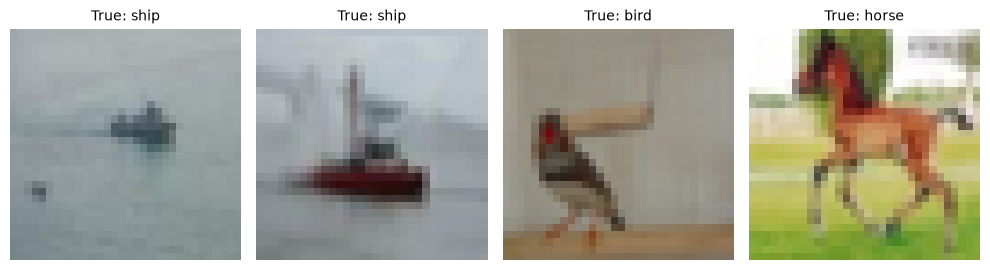

In [15]:
def show_images(images, labels, predictions=None):
    # Undo normalization only for displaying the RGB pixels.
    display_images = (images.detach().cpu() * 0.5 + 0.5).clamp(0, 1)
    fig, axes = plt.subplots(1, len(display_images), figsize=(10, 3), squeeze=False)
    for index, axis in enumerate(axes[0]):
        axis.imshow(display_images[index].permute(1, 2, 0).numpy())
        title = f'True: {class_names[int(labels[index])]}'
        if predictions is not None:
            title += f'\nPredicted: {class_names[int(predictions[index])]}'
        axis.set_title(title, fontsize=10)
        axis.axis('off')
    fig.tight_layout()
    plt.show()

training_images, training_labels = next(iter(train_loader))
show_images(training_images, training_labels)

### Model and training

The grayscale network is adapted to three input channels. Its ten outputs are
logits; `CrossEntropyLoss` accepts those logits and integer class labels directly.
Training follows the tutorial's SGD settings: learning rate 0.001, momentum 0.9,
and two complete epochs. Only training batches update the weights.

In [16]:
class CifarNet(TutorialCNN):
    def __init__(self, first_width=6):
        super().__init__(input_channels=3, first_width=first_width)

torch.manual_seed(SEED)
classifier = CifarNet().to(DEVICE)
classification_loss = nn.CrossEntropyLoss()
classifier_optimizer = optim.SGD(classifier.parameters(), lr=0.001, momentum=0.9)
EPOCHS = 2
print(classifier)
print('Training settings:', {'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
                            'learning_rate': 0.001, 'momentum': 0.9})

CifarNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Training settings: {'epochs': 2, 'batch_size': 4, 'learning_rate': 0.001, 'momentum': 0.9}


In [17]:
train_generator.manual_seed(SEED)
training_history = []
epoch_losses = []
completed_training_batches = 0
training_start = time.perf_counter()
classifier.train()

for epoch in range(EPOCHS):
    epoch_loss_sum = 0.0
    epoch_samples = 0
    window_loss_sum = 0.0
    window_samples = 0
    for batch_number, (images, labels) in enumerate(train_loader, start=1):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        classifier_optimizer.zero_grad(set_to_none=True)
        logits = classifier(images)
        loss = classification_loss(logits, labels)
        loss.backward()
        classifier_optimizer.step()

        batch_count = labels.size(0)
        weighted_loss = loss.item() * batch_count
        epoch_loss_sum += weighted_loss
        epoch_samples += batch_count
        window_loss_sum += weighted_loss
        window_samples += batch_count
        completed_training_batches += 1
        if batch_number % 2000 == 0 or batch_number == len(train_loader):
            mean_window_loss = window_loss_sum / window_samples
            training_history.append({
                'epoch_position': completed_training_batches / len(train_loader),
                'loss': mean_window_loss,
            })
            print(f'Epoch {epoch + 1}, batch {batch_number:5d}/{len(train_loader)}: '
                  f'loss = {mean_window_loss:.4f}', flush=True)
            window_loss_sum = 0.0
            window_samples = 0

    epoch_losses.append(epoch_loss_sum / epoch_samples)
    print(f'Epoch {epoch + 1}: {epoch_samples:,} images, '
          f'mean training loss = {epoch_losses[-1]:.4f}', flush=True)

training_seconds = time.perf_counter() - training_start
print(f'Finished {EPOCHS} epochs in {training_seconds:.1f} seconds.')

Epoch 1, batch  2000/12500: loss = 2.1835


Epoch 1, batch  4000/12500: loss = 1.8184


Epoch 1, batch  6000/12500: loss = 1.6357


Epoch 1, batch  8000/12500: loss = 1.5453


Epoch 1, batch 10000/12500: loss = 1.4960


...

Epoch 2, batch 10000/12500: loss = 1.2960


Epoch 2, batch 12000/12500: loss = 1.2658


Epoch 2, batch 12500/12500: loss = 1.2568


Epoch 2: 50,000 images, mean training loss = 1.3312


Finished 2 epochs in 46.0 seconds.


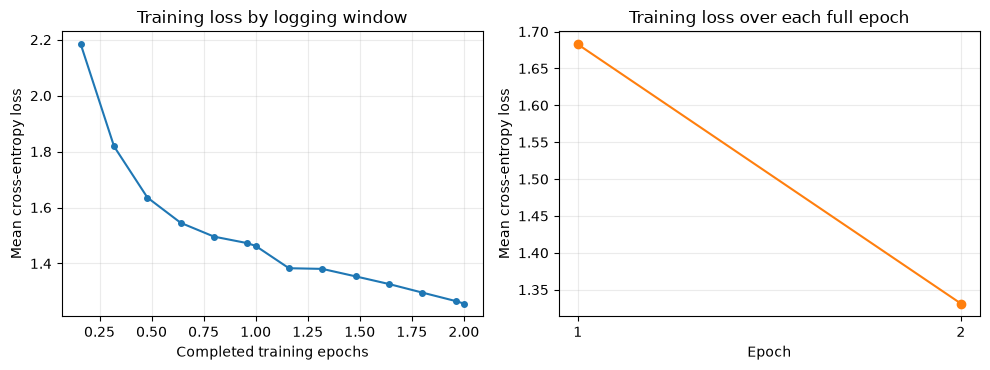

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot([entry['epoch_position'] for entry in training_history],
             [entry['loss'] for entry in training_history], marker='o', markersize=4)
axes[0].set(xlabel='Completed training epochs', ylabel='Mean cross-entropy loss',
            title='Training loss by logging window')
axes[1].plot(range(1, EPOCHS + 1), epoch_losses, marker='o', color='tab:orange')
axes[1].set(xlabel='Epoch', ylabel='Mean cross-entropy loss',
            title='Training loss over each full epoch', xticks=list(range(1, EPOCHS + 1)))
for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Save, reload, and evaluate

The checkpoint contains the learned `state_dict`. Loading it into the same
architecture preserves predictions. Test evaluation uses `eval()` and `no_grad()`;
it performs no optimizer updates. Accuracy counts correct labels, and error rate
counts incorrect labels. Class results use every test image belonging to that class.

Checkpoint: C:\Users\Bayu Febriansyah\Desktop\Important\US\Academics\Semester 3\AE 498 Data Driven Modeling and Optimization\HW3\hw3-nns-main\data\cifar_net.pt
Load result: <All keys matched successfully>
Reloaded predictions match exactly.
True labels: ['cat', 'ship', 'ship', 'airplane']
Predictions: ['bird', 'ship', 'ship', 'ship']


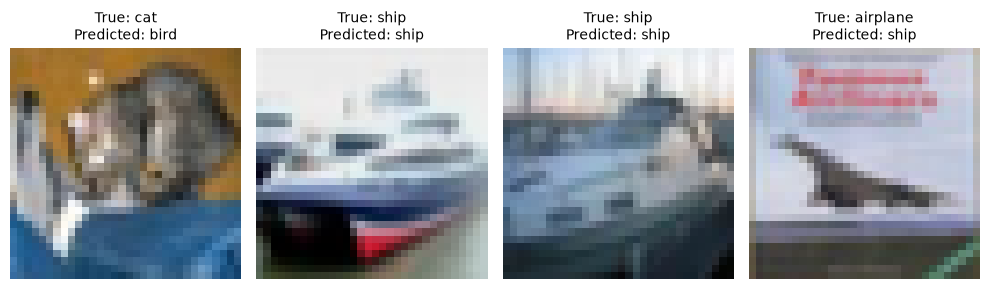

In [19]:
MODEL_PATH = DATA_ROOT / 'cifar_net.pt'
torch.save(classifier.state_dict(), MODEL_PATH)
reloaded_classifier = CifarNet().to(DEVICE)
load_result = reloaded_classifier.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True),
)
classifier.eval()
reloaded_classifier.eval()
test_images, test_labels = next(iter(test_loader))
with torch.no_grad():
    original_logits = classifier(test_images.to(DEVICE))
    reloaded_logits = reloaded_classifier(test_images.to(DEVICE))
torch.testing.assert_close(original_logits, reloaded_logits, rtol=0, atol=0)
example_predictions = reloaded_logits.argmax(dim=1).cpu()
print('Checkpoint:', MODEL_PATH)
print('Load result:', load_result)
print('Reloaded predictions match exactly.')
print('True labels:', [class_names[int(label)] for label in test_labels])
print('Predictions:', [class_names[int(label)] for label in example_predictions])
show_images(test_images, test_labels, example_predictions)

In [20]:
class_total = torch.zeros(len(class_names), dtype=torch.long)
class_correct = torch.zeros_like(class_total)
test_loss_sum = 0.0
with torch.no_grad():
    for images, labels in test_loader:
        logits = reloaded_classifier(images.to(DEVICE))
        device_labels = labels.to(DEVICE)
        predictions = logits.argmax(dim=1).cpu()
        test_loss_sum += F.cross_entropy(logits, device_labels, reduction='sum').item()
        class_total += torch.bincount(labels, minlength=len(class_names))
        class_correct += torch.bincount(labels[predictions == labels],
                                       minlength=len(class_names))

test_total = int(class_total.sum())
test_correct = int(class_correct.sum())
test_accuracy = test_correct / test_total
test_error = 1 - test_accuracy
test_mean_loss = test_loss_sum / test_total
class_accuracies = class_correct.float() / class_total
print(f'Test images evaluated: {test_total:,}')
print(f'Correct predictions: {test_correct:,}')
print(f'Test accuracy: {100 * test_accuracy:.2f}%')
print(f'Test error rate: {100 * test_error:.2f}%')
print(f'Test mean cross-entropy: {test_mean_loss:.4f}')
print('\nClass          Correct / Total     Accuracy')
for name, correct_count, total_count, accuracy in zip(
    class_names, class_correct.tolist(), class_total.tolist(), class_accuracies.tolist()
):
    print(f'{name:12s} {correct_count:5d} / {total_count:<5d}     {100 * accuracy:6.2f}%')

Test images evaluated: 10,000
Correct predictions: 5,487
Test accuracy: 54.87%
Test error rate: 45.13%
Test mean cross-entropy: 1.2699

Class          Correct / Total     Accuracy
airplane       547 / 1000       54.70%
automobile     723 / 1000       72.30%
bird           578 / 1000       57.80%
cat            375 / 1000       37.50%
deer           148 / 1000       14.80%
dog            377 / 1000       37.70%
frog           662 / 1000       66.20%
horse          748 / 1000       74.80%
ship           715 / 1000       71.50%
truck          614 / 1000       61.40%


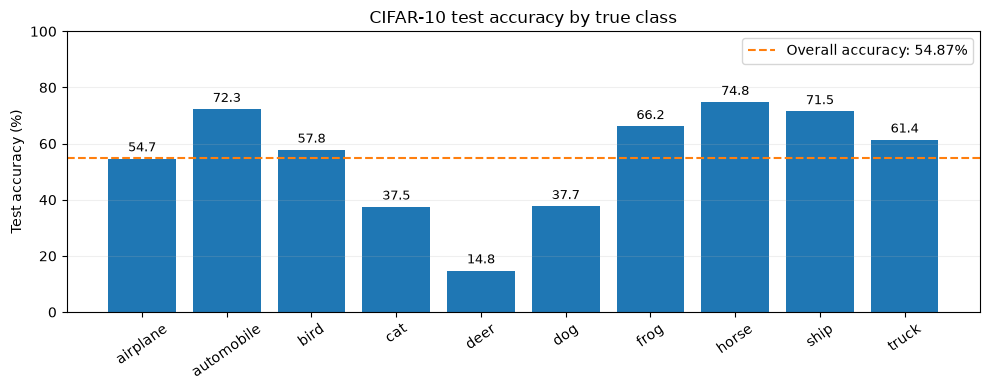

In [21]:
fig, axis = plt.subplots(figsize=(10, 4))
bars = axis.bar(class_names, 100 * class_accuracies.numpy(), color='tab:blue')
axis.axhline(100 * test_accuracy, color='tab:orange', linestyle='--',
             label=f'Overall accuracy: {100 * test_accuracy:.2f}%')
axis.set(ylabel='Test accuracy (%)', ylim=(0, 100),
         title='CIFAR-10 test accuracy by true class')
axis.tick_params(axis='x', rotation=35)
axis.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
axis.legend()
axis.grid(axis='y', alpha=0.2)
fig.tight_layout()
plt.show()

In [22]:
best_class = int(class_accuracies.argmax())
worst_class = int(class_accuracies.argmin())
loss_direction = 'decreased' if epoch_losses[-1] < epoch_losses[0] else 'increased'
chance_comparison = 'above' if test_accuracy > 0.10 else 'at or below'
display(Markdown(
    f'### Interpretation of this execution\n\n'
    f'Mean training loss {loss_direction} from **{epoch_losses[0]:.4f}** in epoch 1 '
    f'to **{epoch_losses[-1]:.4f}** in epoch 2. On all **{test_total:,}** test images, '
    f'accuracy was **{100 * test_accuracy:.2f}%** and error rate was '
    f'**{100 * test_error:.2f}%**. This is {chance_comparison} the 10% expected accuracy '
    f'of a uniform random guess among ten classes.\n\n'
    f'The highest class accuracy was **{class_names[best_class]} '
    f'({100 * class_accuracies[best_class].item():.1f}%)**; the lowest was '
    f'**{class_names[worst_class]} ({100 * class_accuracies[worst_class].item():.1f}%)**. '
    f'These results describe this two-epoch tutorial model. The test split was used '
    f'only after training, and no architecture or training setting was selected '
    f'using its results. A falling training loss alone does not establish generalization '
    f'or diagnose overfitting.'
))

### Interpretation of this execution

Mean training loss decreased from **1.6828** in epoch 1 to **1.3312** in epoch 2. On all **10,000** test images, accuracy was **54.87%** and error rate was **45.13%**. This is above the 10% expected accuracy of a uniform random guess among ten classes.

The highest class accuracy was **horse (74.8%)**; the lowest was **deer (14.8%)**. These results describe this two-epoch tutorial model. The test split was used only after training, and no architecture or training setting was selected using its results. A falling training loss alone does not establish generalization or diagnose overfitting.

### Device transfer and the width exercise

GPU execution requires moving both the model and its input/target tensors to
the device. The classifier training code above already does this when CUDA is
available. For the tutorial's width exercise, the benchmark below doubles the
first convolution's output channels and the second convolution's input channels
together. It measures inference on one fixed batch after warm-up; it does not
train or select another classifier. CPU timings are illustrative and hardware
dependent. A GPU speed comparison is reported only if CUDA is available.

In [23]:
def inference_milliseconds(model, inputs, repeats=50):
    model.eval()
    with torch.no_grad():
        for _ in range(10):
            model(inputs)
        if inputs.device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(repeats):
            model(inputs)
        if inputs.device.type == 'cuda':
            torch.cuda.synchronize()
    return 1000 * (time.perf_counter() - start) / repeats

benchmark_inputs = test_images.clone()
print('First width | Parameter count | CPU ms/batch | GPU ms/batch | CPU/GPU ratio')
for width in (6, 12):
    benchmark_model = CifarNet(first_width=width)
    parameter_count = sum(parameter.numel() for parameter in benchmark_model.parameters())
    cpu_ms = inference_milliseconds(benchmark_model, benchmark_inputs)
    if torch.cuda.is_available():
        benchmark_model = benchmark_model.to('cuda')
        gpu_ms = inference_milliseconds(benchmark_model, benchmark_inputs.to('cuda'))
        print(f'{width:11d} | {parameter_count:15,d} | {cpu_ms:12.3f} | '
              f'{gpu_ms:12.3f} | {cpu_ms / gpu_ms:13.2f}')
    else:
        print(f'{width:11d} | {parameter_count:15,d} | {cpu_ms:12.3f} | '
              f'{"unavailable":>12s} | {"unavailable":>13s}')
if not torch.cuda.is_available():
    print('CUDA is unavailable on this machine; GPU transfer and speedup cannot be measured.')
print('Optional multi-GPU data parallelism requires additional GPU hardware.')

First width | Parameter count | CPU ms/batch | GPU ms/batch | CPU/GPU ratio
          6 |          62,006 |        0.278 |  unavailable |   unavailable


         12 |          64,862 |        0.407 |  unavailable |   unavailable
CUDA is unavailable on this machine; GPU transfer and speedup cannot be measured.
Optional multi-GPU data parallelism requires additional GPU hardware.


## Main takeaways

- Tensor shape, datatype, and device must agree with the operation and model.
- Autograd computes derivatives; optimizers use them to change parameters.
- Gradients accumulate, so a training step clears them before backpropagation.
- `nn.Module` organizes the forward calculation and its learnable parameters.
- Real training uses training data; held-out test predictions assess performance.
- Saved parameters can reproduce predictions when loaded into the same architecture.

The linked tutorials are the references for all four sections. The CIFAR-10
results, plots, derivative checks, and benchmark timings above come from this
notebook's execution.